In [1]:
import matplotlib.pyplot as plt
import numpy as np
import conf_file as conf
import EKF

# loading the data
ground_truth  = np.loadtxt("data/ground_truth_3d_position.csv", delimiter=",", skiprows=1)
camera_sensor = np.loadtxt("data/measurements_2d_camera.csv", delimiter=",", skiprows=1)

# Plot of raw measurements

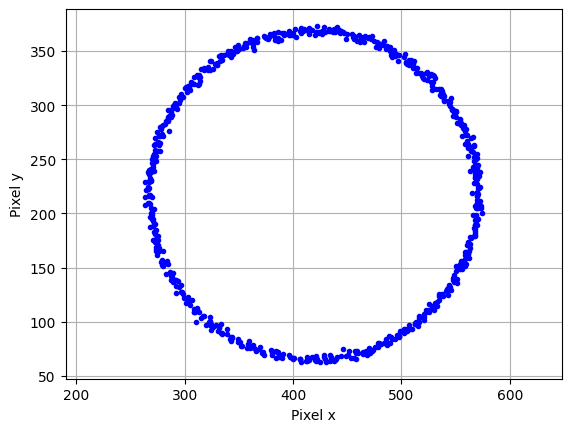

In [2]:
plt.figure()
plt.plot(camera_sensor[:,0], camera_sensor[:,1], '.', color='blue')
plt.xlabel("Pixel x")
plt.ylabel("Pixel y")
plt.axis('equal')
plt.grid()
plt.show()


# EKF with 2D camera
### Initial conditions A

Text(0.5, 0, 'z [m]')

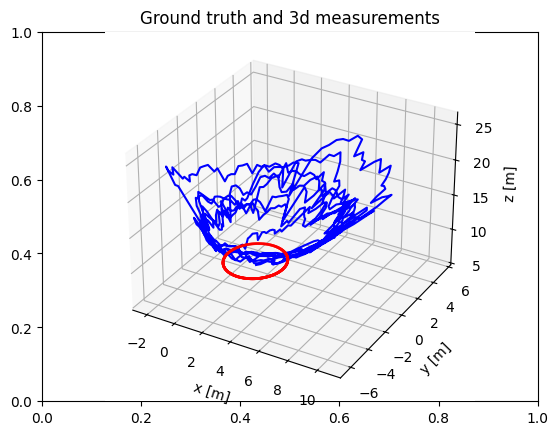

In [3]:
# Kalman filter
P = np.eye(conf.nx)
x = np.array([-0.7, -0.3, 6.6, 0, 0, 0])
x_EKF_A = np.zeros((np.size(camera_sensor[:,0]), conf.nx))
for i in range(np.size(camera_sensor[:,0])):
    # prediction step
    x, P = EKF.prediction(x, conf.A1, P, conf.Q1)
    # update step
    x, P = EKF.update(x, camera_sensor[i,:], conf.h2, conf.H2, P, conf.R2, conf.nx)
    # storing the result
    x_EKF_A[i, :] = x

fig = plt.figure()
plt.title("Ground truth and 3d measurements")
ax = fig.add_subplot(111, projection="3d")
ax.scatter(ground_truth[:,0],ground_truth[:,1],ground_truth[:,2], s=1, color='red')
ax.plot(x_EKF_A[:,0],x_EKF_A[:,1],x_EKF_A[:,2], color='blue')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

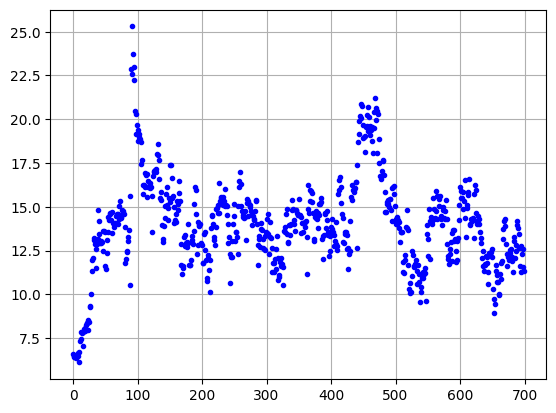

In [6]:
plt.figure()
plt.plot(x_EKF_A[:,2], '.', color='blue')
plt.grid()
plt.show()